# Uji Skenario — Abstractive Summarization
Lima skenario pengujian memakai hasil ringkasan yang sudah ada (`merge_abstractive.csv`).
Skenario 3 memakai `data_no_preprocessing.csv` untuk teks mentah.

**Urutan dioptimalkan:** Skenario 4 (cari model terbaik) dijalankan lebih dulu.

| Skenario | Metrik | Data |
|----------|--------|------|
| 4. Tiga model | ROUGE + BERTScore | Penuh / sampel BERTScore |
| 1. Panjang artikel | ROUGE | Penuh |
| 2. Kategori | ROUGE | Penuh |
| 3. Preprocessing | ROUGE | Sampel 300 (regenerate model, BERAT) |
| 5. vs Extractive | ROUGE + BERTScore | Dataset sama |

> **Catatan data:** semua `global_id` di merge_abstractive ada di data_no_preprocessing,
> jadi Skenario 3 mengambil `article_text` mentah lewat merge by `global_id`.
>
> **Beda dari extractive:** Skenario 3 abstractive HARUS regenerate inferensi model
> generatif (berat). Maka sampel lebih kecil (N=300) + pembebasan memori GPU.

---
## Persiapan

### Setup

In [1]:
!pip install transformers sentencepiece rouge-score bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 768.0 kB/s eta 0:00:00


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from tqdm import tqdm
tqdm.pandas()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


### Load Kedua Dataset

In [3]:
BASE = '/kaggle/input/datasets/nazhifberlian/dataujiabstractive'

# Data hasil preprocessing + ringkasan tiga model abstractive (untuk semua skenario)
df = pd.read_csv('/kaggle/input/datasets/nazhifberlian/dataujiabstractive/merge_abstractive.csv', encoding='utf-8-sig')

# Data tanpa preprocessing (khusus Skenario 3)
df_raw = pd.read_csv('/kaggle/input/datasets/nazhifberlian/dataujiabstractive/data_no_preprocessing (1).csv', encoding='utf-8-sig')

print(f'merge_abstractive    : {len(df)} baris, kolom: {list(df.columns)}')
print(f'data_no_preprocessing: {len(df_raw)} baris')
print(f'\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

merge_abstractive    : 12644 baris, kolom: ['global_id', 'title', 'category', 'summary_indobart', 'summary_t5', 'summary_pegasus', 'lead_paragraph', 'body_word_count']
data_no_preprocessing: 13444 baris

Distribusi kategori:
category
sejarah     1976
arts        1962
artis       1947
kuliner     1947
tech        1716
biografi    1679
sains       1417


### Setup ROUGE

In [4]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

def rouge_avg(pred_series, ref_series):
    r1, r2, rl = [], [], []
    for pred, ref in zip(pred_series, ref_series):
        s = scorer.score(str(ref), str(pred))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return np.mean(r1), np.mean(r2), np.mean(rl)

models = [
    ('IndoBART', 'summary_indobart'),
    ('T5',       'summary_t5'),
    ('PEGASUS',  'summary_pegasus'),
]

print('ROUGE scorer siap.')

ROUGE scorer siap.


---
## Skenario 4 — Perbandingan Tiga Model

### 4a. ROUGE

In [5]:
# ============================================================
# SKENARIO 4 — Perbandingan Tiga Model Abstractive
# ============================================================
# Dijalankan pertama untuk menentukan model terbaik yang dipakai skenario lain.

rows = []
for name, col in models:
    r1, r2, rl = rouge_avg(df[col], df['lead_paragraph'])
    rows.append({'model': name, 'rouge1': r1, 'rouge2': r2, 'rougeL': rl})

hasil_model = pd.DataFrame(rows)
print('Perbandingan ROUGE tiga model abstractive:')
print('=' * 55)
print(hasil_model.round(4).to_string(index=False))

best_row = hasil_model.loc[hasil_model['rougeL'].idxmax()]
MODEL_TERBAIK_NAMA = best_row['model']
MODEL_TERBAIK_KOL = dict(models)[MODEL_TERBAIK_NAMA]
print(f'\nModel terbaik (ROUGE-L): {MODEL_TERBAIK_NAMA}')

Perbandingan ROUGE tiga model abstractive:
   model  rouge1  rouge2  rougeL
IndoBART  0.1671  0.0384  0.1144
      T5  0.1723  0.0395  0.1156
 PEGASUS  0.1591  0.0373  0.1122

Model terbaik (ROUGE-L): T5


### 4b. BERTScore

In [6]:
# BERTScore tiga model (sampel N=500). Penting untuk abstractive yang memparafrase.
SAMPLE_SIZE_BS = 500
sample_bs = df.sample(n=min(SAMPLE_SIZE_BS, len(df)), random_state=42).reset_index(drop=True)
refs_bs = sample_bs['lead_paragraph'].astype(str).tolist()

rows = []
hasil_bertscore = {}
for name, col in models:
    P, R, F1 = bertscore(sample_bs[col].astype(str).tolist(), refs_bs, lang='id', verbose=False)
    hasil_bertscore[name] = (P.mean().item(), R.mean().item(), F1.mean().item())
    rows.append({'model': name, 'precision': P.mean().item(),
                 'recall': R.mean().item(), 'f1': F1.mean().item()})

print(f'BERTScore tiga model abstractive (sampel N={len(sample_bs)}):')
print('=' * 55)
print(pd.DataFrame(rows).round(4).to_string(index=False))

best_bs = max(hasil_bertscore, key=lambda k: hasil_bertscore[k][2])
print(f'\nTerbaik menurut BERTScore-F1: {best_bs}')

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore tiga model abstractive (sampel N=500):
   model  precision  recall     f1
IndoBART     0.6875  0.6454 0.6653
      T5     0.6809  0.6465 0.6627
 PEGASUS     0.6858  0.6367 0.6599

Terbaik menurut BERTScore-F1: IndoBART


---
## Skenario 1 — Pengaruh Panjang Artikel

In [7]:
# ============================================================
# SKENARIO 1 — Pengaruh Panjang Artikel
# ============================================================
def length_group(wc):
    if wc < 300:
        return '1_Pendek (<300)'
    elif wc <= 500:
        return '2_Sedang (300-500)'
    else:
        return '3_Panjang (>500)'

df['length_group'] = df['body_word_count'].apply(length_group)

rows = []
for grp in sorted(df['length_group'].unique()):
    sub = df[df['length_group'] == grp]
    r1, r2, rl = rouge_avg(sub[MODEL_TERBAIK_KOL], sub['lead_paragraph'])
    rows.append({'kelompok': grp, 'jumlah': len(sub), 'rouge1': r1, 'rougeL': rl})

hasil_panjang = pd.DataFrame(rows)
print(f'Pengaruh panjang artikel ({MODEL_TERBAIK_NAMA}):')
print('=' * 55)
print(hasil_panjang.round(4).to_string(index=False))

Pengaruh panjang artikel (T5):
          kelompok  jumlah  rouge1  rougeL
   1_Pendek (<300)    6270  0.1703  0.1160
2_Sedang (300-500)    2902  0.1817  0.1218
  3_Panjang (>500)    3472  0.1679  0.1096


---
## Skenario 2 — Pengaruh Kategori

In [8]:
# ============================================================
# SKENARIO 2 — Pengaruh Kategori
# ============================================================
rows = []
for kat in sorted(df['category'].unique()):
    sub = df[df['category'] == kat]
    r1, r2, rl = rouge_avg(sub[MODEL_TERBAIK_KOL], sub['lead_paragraph'])
    rows.append({'kategori': kat, 'jumlah': len(sub), 'rouge1': r1, 'rougeL': rl})

hasil_kategori = pd.DataFrame(rows).sort_values('rougeL', ascending=False)
print(f'Pengaruh kategori ({MODEL_TERBAIK_NAMA}):')
print('=' * 55)
print(hasil_kategori.round(4).to_string(index=False))
print(f'\nTertinggi: {hasil_kategori.iloc[0]["kategori"]} ({hasil_kategori.iloc[0]["rougeL"]:.4f})')
print(f'Terendah : {hasil_kategori.iloc[-1]["kategori"]} ({hasil_kategori.iloc[-1]["rougeL"]:.4f})')

Pengaruh kategori (T5):
kategori  jumlah  rouge1  rougeL
 sejarah    1976  0.1818  0.1216
biografi    1679  0.1646  0.1188
 kuliner    1947  0.1772  0.1185
    tech    1716  0.1744  0.1147
    arts    1962  0.1712  0.1133
   artis    1947  0.1698  0.1127
   sains    1417  0.1637  0.1075

Tertinggi: sejarah (0.1216)
Terendah : sains (0.1075)


---
## Skenario 3 — Pengaruh Preprocessing

### 3a. Muat model terbaik (untuk regenerate teks tanpa preprocessing)

In [9]:
# ============================================================
# SKENARIO 3 — Pengaruh Preprocessing
# ============================================================
# Bandingkan ringkasan dari teks SUDAH preprocessing (di merge_abstractive)
# vs teks TANPA preprocessing (article_text mentah di data_no_preprocessing).
#
# BERBEDA DARI EXTRACTIVE: abstractive HARUS menjalankan ulang inferensi model
# generatif (berat, butuh GPU). Maka:
#   - versi "dengan preprocessing" memakai hasil yang SUDAH ada (tidak regenerate)
#   - versi "tanpa preprocessing" digenerasi ulang HANYA pada sampel kecil (N=300)
#
# Muat model terbaik (pemenang Skenario 4).
MODEL_CHECKPOINT = {
    'IndoBART': 'gaduhhartawan/indobart-base',
    'T5':       'cahya/t5-base-indonesian-summarization-cased',
    'PEGASUS':  'thonyyy/pegasus_indonesian_base-finetune',
}[MODEL_TERBAIK_NAMA]

print(f'Memuat model terbaik: {MODEL_CHECKPOINT}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
# from_tf=True hanya untuk PEGASUS; aman diabaikan model lain jika tidak perlu.
try:
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT).to(DEVICE)
except Exception:
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT, from_tf=True).to(DEVICE)
model.eval()
print('Model siap.')

Memuat model terbaik: cahya/t5-base-indonesian-summarization-cased


config.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/793k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model siap.


### 3b. Generate ulang & bandingkan (+ bebaskan memori GPU)

In [10]:
MAX_INPUT_TOKENS  = 512
MAX_OUTPUT_TOKENS = 128
MIN_OUTPUT_TOKENS = 30
MAX_SENTENCES_PER_CHUNK = 20

def split_sentences(text):
    return [s.strip() for s in sent_tokenize(str(text)) if len(s.split()) >= 4]

def summarize_transformer(text):
    inputs = tokenizer(str(text), return_tensors='pt',
                       max_length=MAX_INPUT_TOKENS, truncation=True).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=MAX_OUTPUT_TOKENS,
                                    min_new_tokens=MIN_OUTPUT_TOKENS, num_beams=4,
                                    early_stopping=True, no_repeat_ngram_size=3, length_penalty=1.0)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

def summarize_with_chunking(text):
    sentences = split_sentences(text)
    if len(sentences) <= MAX_SENTENCES_PER_CHUNK:
        return summarize_transformer(text)
    chunks = [sentences[i:i+MAX_SENTENCES_PER_CHUNK]
              for i in range(0, len(sentences), MAX_SENTENCES_PER_CHUNK)]
    chunk_summaries = [summarize_transformer(' '.join(c)) for c in chunks]
    return summarize_transformer(' '.join(chunk_summaries))

# Sampel kecil karena inferensi generatif berat
SAMPLE_SIZE_PRE = 300
sample3 = df.sample(n=min(SAMPLE_SIZE_PRE, len(df)), random_state=42).reset_index(drop=True)
sample3 = sample3.merge(df_raw[['global_id', 'article_text']], on='global_id', how='left')

# Versi DENGAN preprocessing: pakai hasil yang SUDAH ada
sample3['sum_with'] = sample3[MODEL_TERBAIK_KOL]
# Versi TANPA preprocessing: generate ulang dari article_text mentah
sample3['sum_without'] = [summarize_with_chunking(t)
                          for t in tqdm(sample3['article_text'], desc='Regenerate tanpa preprocessing')]

with_scores = rouge_avg(sample3['sum_with'], sample3['lead_paragraph'])
without_scores = rouge_avg(sample3['sum_without'], sample3['lead_paragraph'])

print(f'Pengaruh preprocessing ({MODEL_TERBAIK_NAMA}, sampel N={len(sample3)}):')
print('=' * 58)
print(f'{"":22} | {"ROUGE-1":>8} | {"ROUGE-2":>8} | {"ROUGE-L":>8}')
print('-' * 58)
print(f'{"Dengan preprocessing":22} | {with_scores[0]:>8.4f} | {with_scores[1]:>8.4f} | {with_scores[2]:>8.4f}')
print(f'{"Tanpa preprocessing":22} | {without_scores[0]:>8.4f} | {without_scores[1]:>8.4f} | {without_scores[2]:>8.4f}')
print('-' * 58)
selisih = with_scores[2] - without_scores[2]
print(f'Selisih ROUGE-L: {selisih:+.4f} ({selisih / without_scores[2] * 100:+.1f}%)')

# Bebaskan memori GPU
import gc
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\nMemori GPU dibebaskan.')

Regenerate tanpa preprocessing:   0%|          | 0/300 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Regenerate tanpa preprocessing: 100%|██████████| 300/300 [1:08:43<00:00, 13.75s/it]


Pengaruh preprocessing (T5, sampel N=300):
                       |  ROUGE-1 |  ROUGE-2 |  ROUGE-L
----------------------------------------------------------
Dengan preprocessing   |   0.1656 |   0.0348 |   0.1095
Tanpa preprocessing    |   0.1667 |   0.0384 |   0.1125
----------------------------------------------------------
Selisih ROUGE-L: -0.0030 (-2.7%)

Memori GPU dibebaskan.


---
## Skenario 5 — Abstractive Terbaik vs Extractive Terbaik

In [11]:
# ============================================================
# SKENARIO 5 — Abstractive Terbaik vs Extractive Terbaik
# ============================================================
# Kedua skor dihitung LIVE dari CSV masing-masing agar tidak ada
# angka tetap yang bisa kedaluwarsa. Dataset identik (global_id sama).

df_ext = pd.read_csv('/kaggle/input/datasets/nazhifberlian/dataujiabstractive/merge_extractive.csv',
                     encoding='utf-8-sig')

# Tentukan model extractive terbaik (ROUGE-L)
models_ext = [('TF-IDF','summary_tf_idf'),('TextRank','summary_textrank'),('BERT','summary_bert')]
rows_ext = []
for name, col in models_ext:
    r1, r2, rl = rouge_avg(df_ext[col], df_ext['lead_paragraph'])
    rows_ext.append({'model': name, 'rougeL': rl, 'col': col})
best_ext = max(rows_ext, key=lambda x: x['rougeL'])

ext_r1, ext_r2, ext_rl = rouge_avg(df_ext[best_ext['col']], df_ext['lead_paragraph'])

# BERTScore extractive terbaik (sampel sama: seed=42, N=500)
sample_ext = df_ext.sample(n=min(500, len(df_ext)), random_state=42).reset_index(drop=True)
_, _, F1_ext = bertscore(sample_ext[best_ext['col']].astype(str).tolist(),
                         sample_ext['lead_paragraph'].astype(str).tolist(),
                         lang='id', verbose=False)
ext_bs_f1 = F1_ext.mean().item()

# Abstractive terbaik sudah ada dari Skenario 4
abs_r1, abs_r2, abs_rl = rouge_avg(df[MODEL_TERBAIK_KOL], df['lead_paragraph'])
abs_bs_f1 = hasil_bertscore[MODEL_TERBAIK_NAMA][2]

print('Perbandingan Abstractive Terbaik vs Extractive Terbaik:')
print('=' * 62)
print(f'{"Pendekatan":<26} | {"ROUGE-1":>8} | {"ROUGE-L":>8} | {"BERTScore":>9}')
print('-' * 62)
print(f'{f"Abstractive ({MODEL_TERBAIK_NAMA})":<26} | {abs_r1:>8.4f} | {abs_rl:>8.4f} | {abs_bs_f1:>9.4f}')
print(f'{f"Extractive ({best_ext["model"]})":<26} | {ext_r1:>8.4f} | {ext_rl:>8.4f} | {ext_bs_f1:>9.4f}')
print('=' * 62)

menang_rouge = MODEL_TERBAIK_NAMA if abs_rl > ext_rl else best_ext['model']
menang_bs    = MODEL_TERBAIK_NAMA if abs_bs_f1 > ext_bs_f1 else best_ext['model']
print('\nKesimpulan:')
print(f'  Menurut ROUGE-L   : {menang_rouge} unggul')
print(f'  Menurut BERTScore : {menang_bs} unggul')
if menang_rouge != menang_bs:
    print('  -> Pemenang berbeda antar metrik: tiap pendekatan unggul di aspek berbeda.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Perbandingan Abstractive Terbaik vs Extractive Terbaik:
Pendekatan                 |  ROUGE-1 |  ROUGE-L | BERTScore
--------------------------------------------------------------
Abstractive (T5)           |   0.1723 |   0.1156 |    0.6627
Extractive (TextRank)      |   0.2024 |   0.1269 |    0.6687

Kesimpulan:
  Menurut ROUGE-L   : TextRank unggul
  Menurut BERTScore : TextRank unggul


---
## Visualisasi Semua Skenario

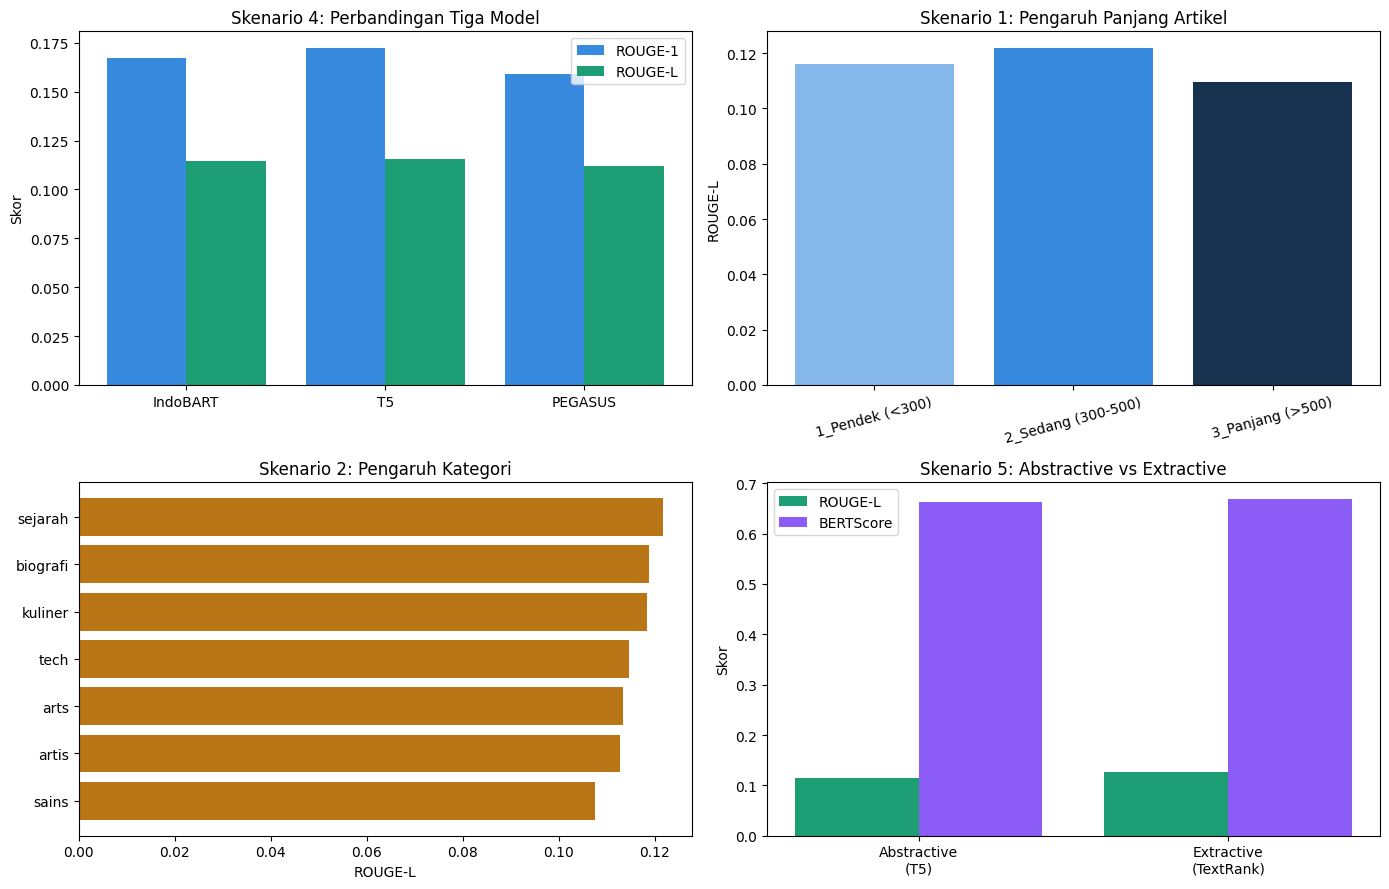

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

x = np.arange(len(hasil_model))
ax[0,0].bar(x - 0.2, hasil_model['rouge1'], 0.4, label='ROUGE-1', color='#378ADD')
ax[0,0].bar(x + 0.2, hasil_model['rougeL'], 0.4, label='ROUGE-L', color='#1D9E75')
ax[0,0].set_xticks(x); ax[0,0].set_xticklabels(hasil_model['model'])
ax[0,0].set_title('Skenario 4: Perbandingan Tiga Model')
ax[0,0].set_ylabel('Skor'); ax[0,0].legend()

ax[0,1].bar(hasil_panjang['kelompok'], hasil_panjang['rougeL'],
            color=['#85B7EB', '#378ADD', '#16324f'])
ax[0,1].set_title('Skenario 1: Pengaruh Panjang Artikel')
ax[0,1].set_ylabel('ROUGE-L'); ax[0,1].tick_params(axis='x', rotation=15)

ax[1,0].barh(hasil_kategori['kategori'], hasil_kategori['rougeL'], color='#BA7517')
ax[1,0].set_title('Skenario 2: Pengaruh Kategori')
ax[1,0].set_xlabel('ROUGE-L'); ax[1,0].invert_yaxis()

pendekatan = [f'Abstractive\n({MODEL_TERBAIK_NAMA})', f'Extractive\n({best_ext["model"]})']
rouge_vals = [abs_rl, ext_rl]
bert_vals = [abs_bs_f1, ext_bs_f1]
xp = np.arange(len(pendekatan))
ax[1,1].bar(xp - 0.2, rouge_vals, 0.4, label='ROUGE-L', color='#1D9E75')
ax[1,1].bar(xp + 0.2, bert_vals, 0.4, label='BERTScore', color='#8B5CF6')
ax[1,1].set_xticks(xp); ax[1,1].set_xticklabels(pendekatan)
ax[1,1].set_title('Skenario 5: Abstractive vs Extractive')
ax[1,1].set_ylabel('Skor'); ax[1,1].legend()

plt.tight_layout(); plt.show()